In [118]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr  # para correlaciones de perfiles

# Carga del dataset base
df_all = pd.read_parquet("df_all_procesado.parquet")

df_all.head(), df_all.columns


(      pickup_datetime    dropOff_datetime  PUlocationID  DOlocationID  month  \
 0 2024-07-01 00:48:33 2024-07-01 01:10:50         137.0         151.0      7   
 1 2024-07-01 00:12:37 2024-07-01 00:25:04         164.0          50.0      7   
 2 2024-07-01 00:13:34 2024-07-01 00:29:53         249.0         100.0      7   
 3 2024-07-01 00:34:56 2024-07-01 00:51:09         164.0          87.0      7   
 4 2024-07-01 00:19:42 2024-07-01 00:36:52         164.0         148.0      7   
 
   weekday  year tipo        date  
 0  Monday  2024  fhv  2024-07-01  
 1  Monday  2024  fhv  2024-07-01  
 2  Monday  2024  fhv  2024-07-01  
 3  Monday  2024  fhv  2024-07-01  
 4  Monday  2024  fhv  2024-07-01  ,
 Index(['pickup_datetime', 'dropOff_datetime', 'PUlocationID', 'DOlocationID',
        'month', 'weekday', 'year', 'tipo', 'date'],
       dtype='object'))

In [119]:
# Asegurar tipo datetime
df_all["pickup_datetime"] = pd.to_datetime(df_all["pickup_datetime"])

# Componentes de tiempo básicos
df_all["date"]    = df_all["pickup_datetime"].dt.date
df_all["weekday"] = df_all["pickup_datetime"].dt.weekday   # 0=lun,...,6=dom
df_all["hour"]    = df_all["pickup_datetime"].dt.hour
df_all["minute"]  = df_all["pickup_datetime"].dt.minute
df_all["year"]    = df_all["pickup_datetime"].dt.year

# Bucket de 15 minutos: 24h * 4 = 96 buckets
df_all["bucket15"] = df_all["hour"] * 4 + (df_all["minute"] // 15)

df_all[["pickup_datetime", "date", "weekday", "hour", "minute", "bucket15"]].head()


,pickup_datetime,date,weekday,hour,minute,bucket15
0,2024-07-01 00:48:33,2024-07-01,0,0,48,3
1,2024-07-01 00:12:37,2024-07-01,0,0,12,0
2,2024-07-01 00:13:34,2024-07-01,0,0,13,0
3,2024-07-01 00:34:56,2024-07-01,0,0,34,2
4,2024-07-01 00:19:42,2024-07-01,0,0,19,1


In [120]:
# Filtrar df_all para quedarnos solo con años 2024 y 2025 y reportar si se eliminaron filas
# (si por alguna razón no existe la columna 'year', la extraemos de pickup_datetime)
if "year" not in df_all.columns:
    df_all["year"] = df_all["pickup_datetime"].dt.year
antes = len(df_all)
df_all = df_all[df_all["year"].isin([2024, 2025])].reset_index(drop=True)
despues = len(df_all)
eliminados = antes - despues
print(f"Registros antes: {antes}")
print(f"Registros después: {despues}")
print(f"Registros eliminados: {eliminados}")
if eliminados > 0:
    print("Se eliminaron registros que no correspondían a 2024 o 2025.")
else:
    print("No se eliminó ningún registro (todos son 2024 o 2025).")

Registros antes: 36185635
Registros después: 36185632
Registros eliminados: 3
Se eliminaron registros que no correspondían a 2024 o 2025.


In [121]:
# Número de viajes por día, weekday y bucket15
demand_15 = (
    df_all
    .groupby(["date", "weekday", "bucket15"])
    .size()
    .reset_index(name="viajes")
)

demand_15.head()


,date,weekday,bucket15,viajes
0,2024-07-01,0,0,507
1,2024-07-01,0,1,429
2,2024-07-01,0,2,359
3,2024-07-01,0,3,332
4,2024-07-01,0,4,306


In [122]:
# Total de viajes por día (suma de los buckets de 15 min)
trips_per_day = (
    demand_15
    .groupby("date")["viajes"]
    .sum()
    .reset_index(name="viajes_dia")
)

# ordenar por fecha (asegura orden cronológico)
trips_per_day["date_dt"] = pd.to_datetime(trips_per_day["date"])
trips_per_day = trips_per_day.sort_values("date_dt").reset_index(drop=True)

# Mostrar resumen y ejemplos
print("Número de días en el dataset:", len(trips_per_day))
print("\nPrimeras 10 filas (fecha -> viajes):")
print(trips_per_day[["date", "viajes_dia"]].head(10))

# Ejemplo concreto: intentar con 2025-01-01, si existe; si no, mostrar el primer día disponible
fecha_ej = "2025-01-01"
if fecha_ej in trips_per_day["date"].values:
    cnt = trips_per_day.loc[trips_per_day["date"] == fecha_ej, "viajes_dia"].iat[0]
    print(f"\nEjemplo: fecha {fecha_ej} -> viajes: {cnt}")
else:
    primera_fecha = trips_per_day.at[0, "date"]
    cnt = trips_per_day.at[0, "viajes_dia"]
    print(f"\nFecha {fecha_ej} no encontrada. Primer día disponible: {primera_fecha} -> viajes: {cnt}")

Número de días en el dataset: 351

Primeras 10 filas (fecha -> viajes):
         date  viajes_dia
0  2024-07-01       68450
1  2024-07-02       73655
2  2024-07-03       66699
3  2024-07-05       61158
4  2024-07-06       61568
5  2024-07-07       56706
6  2024-07-08       73014
7  2024-07-09       94085
8  2024-07-10      103005
9  2024-07-11      100560

Fecha 2025-01-01 no encontrada. Primer día disponible: 2024-07-01 -> viajes: 68450


In [123]:
daily_profiles = demand_15.pivot_table(
    index=["date", "weekday"],
    columns="bucket15",
    values="viajes",
    fill_value=0
)

bucket_cols = daily_profiles.columns.tolist()
daily_profiles.head()


,bucket15,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
date,weekday,,,,,,,,,,,,,,,,,,,,,
2024-07-01,0,507.0,429.0,359.0,332.0,306.0,228.0,219.0,180.0,156.0,127.0,...,908.0,823.0,916.0,784.0,669.0,554.0,552.0,466.0,374.0,318.0
2024-07-02,1,326.0,227.0,165.0,148.0,114.0,107.0,104.0,62.0,78.0,55.0,...,1053.0,1133.0,1113.0,1014.0,919.0,786.0,695.0,590.0,481.0,444.0
2024-07-03,2,315.0,312.0,236.0,169.0,150.0,156.0,119.0,99.0,87.0,79.0,...,784.0,757.0,879.0,856.0,694.0,690.0,666.0,617.0,506.0,486.0
2024-07-05,4,569.0,518.0,446.0,397.0,268.0,242.0,243.0,244.0,188.0,159.0,...,773.0,758.0,778.0,763.0,684.0,687.0,611.0,570.0,560.0,504.0
2024-07-06,5,465.0,379.0,328.0,317.0,331.0,287.0,266.0,268.0,262.0,241.0,...,839.0,849.0,888.0,851.0,911.0,844.0,810.0,738.0,640.0,626.0


In [124]:
daily_totals = daily_profiles.sum(axis=1)
daily_totals_df = daily_totals.reset_index(name="total_viajes")
daily_totals_df.head()


,date,weekday,total_viajes
0,2024-07-01,0,68450.0
1,2024-07-02,1,73655.0
2,2024-07-03,2,66699.0
3,2024-07-05,4,61158.0
4,2024-07-06,5,61568.0


In [125]:
daily_shapes = daily_profiles.div(daily_totals, axis=0)
daily_shapes_df = daily_shapes.reset_index()
daily_shapes_df.head()


bucket15,date,weekday,0,1,2,3,4,5,6,7,...,86,87,88,89,90,91,92,93,94,95
0,2024-07-01,0,0.007407,0.006267,0.005245,0.004850,0.004470,0.003331,0.003199,0.002630,...,0.013265,0.012023,0.013382,0.011454,0.009774,0.008093,0.008064,0.006808,0.005464,0.004646
1,2024-07-02,1,0.004426,0.003082,0.002240,0.002009,0.001548,0.001453,0.001412,0.000842,...,0.014296,0.015383,0.015111,0.013767,0.012477,0.010671,0.009436,0.008010,0.006530,0.006028
2,2024-07-03,2,0.004723,0.004678,0.003538,0.002534,0.002249,0.002339,0.001784,0.001484,...,0.011754,0.011349,0.013179,0.012834,0.010405,0.010345,0.009985,0.009251,0.007586,0.007286
3,2024-07-05,4,0.009304,0.008470,0.007293,0.006491,0.004382,0.003957,0.003973,0.003990,...,0.012639,0.012394,0.012721,0.012476,0.011184,0.011233,0.009991,0.009320,0.009157,0.008241
4,2024-07-06,5,0.007553,0.006156,0.005327,0.005149,0.005376,0.004662,0.004320,0.004353,...,0.013627,0.013790,0.014423,0.013822,0.014797,0.013708,0.013156,0.011987,0.010395,0.010168


In [126]:
def marcar_outliers_totales(df_tot: pd.DataFrame, k: float = 2.5):
    df_tot = df_tot.copy()
    df_tot["outlier_total"] = False

    for w in range(7):
        mask = df_tot["weekday"] == w
        datos_w = df_tot.loc[mask, "total_viajes"]

        # si hay muy pocos días de ese weekday, no marcamos nada
        if len(datos_w) < 10:
            continue

        q1 = datos_w.quantile(0.25)
        q3 = datos_w.quantile(0.75)
        iqr = q3 - q1

        low  = q1 - k * iqr
        high = q3 + k * iqr

        df_tot.loc[mask & ((df_tot["total_viajes"] < low) | (df_tot["total_viajes"] > high)), "outlier_total"] = True

    return df_tot

daily_totals_df = marcar_outliers_totales(daily_totals_df, k=2.5)
daily_totals_df["outlier_total"].value_counts()


outlier_total
False    347
True       4
Name: count, dtype: int64

In [127]:
bucket_cols = [c for c in daily_shapes_df.columns if isinstance(c, int)]

weekday_shapes = (
    daily_shapes_df
    .groupby("weekday")[bucket_cols]
    .mean()
)
weekday_shapes.head()


bucket15,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
weekday,,,,,,,,,,,,,,,,,,,,,
0,0.003651,0.002827,0.002347,0.001998,0.001663,0.001329,0.001202,0.001099,0.000960,0.000816,...,0.014342,0.013799,0.013009,0.011574,0.010083,0.008726,0.007517,0.006307,0.005216,0.004385
1,0.003444,0.002683,0.002151,0.001727,0.001417,0.001149,0.000982,0.000823,0.000766,0.000606,...,0.017838,0.017378,0.016553,0.014866,0.012996,0.011308,0.009832,0.008079,0.006551,0.005259
2,0.004318,0.003384,0.002576,0.002083,0.001728,0.001405,0.001182,0.000994,0.000918,0.000744,...,0.017457,0.017084,0.016893,0.015552,0.014254,0.012916,0.011109,0.009230,0.007536,0.006304
3,0.005085,0.004161,0.003297,0.002665,0.002219,0.001809,0.001519,0.001297,0.001152,0.001007,...,0.017081,0.017038,0.016992,0.016113,0.015101,0.013863,0.012845,0.011664,0.010262,0.009066
4,0.008593,0.007333,0.006222,0.005296,0.004462,0.003776,0.003281,0.002970,0.002671,0.002209,...,0.014371,0.014814,0.015246,0.014846,0.014915,0.014926,0.014885,0.014576,0.014509,0.014163


In [128]:
def calcular_corr_shape(daily_shapes_df, weekday_shapes):
    res = []
    for _, row in daily_shapes_df.iterrows():
        w = row["weekday"]
        shape_dia = row[bucket_cols].values.astype(float)
        shape_ref = weekday_shapes.loc[w].values.astype(float)

        # si un día tiene total casi cero, la forma no es muy informativa
        if shape_dia.sum() == 0 or shape_ref.sum() == 0:
            corr = np.nan
        else:
            corr, _ = pearsonr(shape_dia, shape_ref)
        res.append(corr)

    daily_shapes_df = daily_shapes_df.copy()
    daily_shapes_df["corr_shape_weekday"] = res
    return daily_shapes_df

daily_shapes_df = calcular_corr_shape(daily_shapes_df, weekday_shapes)
daily_shapes_df[["date", "weekday", "corr_shape_weekday"]].head()


bucket15,date,weekday,corr_shape_weekday
0,2024-07-01,0,0.982947
1,2024-07-02,1,0.970344
2,2024-07-03,2,0.907119
3,2024-07-05,4,0.900423
4,2024-07-06,5,0.912300


In [129]:
umbral_corr = 0.85
daily_shapes_df["outlier_shape"] = daily_shapes_df["corr_shape_weekday"] < umbral_corr
daily_shapes_df["outlier_shape"].value_counts(dropna=False)


outlier_shape
False    350
True       1
Name: count, dtype: int64

In [130]:
hol = daily_totals_df.merge(
    daily_shapes_df[["date", "weekday", "corr_shape_weekday", "outlier_shape"]],
    on=["date", "weekday"],
    how="left"
)

hol["is_holiday_like"] = hol["outlier_total"] | hol["outlier_shape"]

hol[["date", "weekday", "total_viajes", "outlier_total", "corr_shape_weekday", "outlier_shape", "is_holiday_like"]].head()


,date,weekday,total_viajes,outlier_total,corr_shape_weekday,outlier_shape,is_holiday_like
0,2024-07-01,0,68450.0,False,0.982947,False,False
1,2024-07-02,1,73655.0,False,0.970344,False,False
2,2024-07-03,2,66699.0,True,0.907119,False,True
3,2024-07-05,4,61158.0,False,0.900423,False,False
4,2024-07-06,5,61568.0,False,0.912300,False,False


In [131]:
holiday_map = hol.set_index("date")["is_holiday_like"].to_dict()

df_all["is_holiday_like"] = df_all["date"].map(holiday_map)

df_normal = df_all[~df_all["is_holiday_like"].fillna(False)].copy()

print("Viajes totales (df original):", len(df_all))
print("Viajes totales (df_normal):", len(df_normal))

print("\nDías únicos (df):", df_all["date"].nunique())
print("Días únicos (df_normal):", df_normal["date"].nunique())

dias_drop = df_all["date"].nunique() - df_normal["date"].nunique()
print("\nDías eliminados:", dias_drop)
print("Proporción días eliminados:", dias_drop / df_all["date"].nunique())


Viajes totales (df original): 36185632
Viajes totales (df_normal): 35830335

Días únicos (df): 351
Días únicos (df_normal): 346

Días eliminados: 5
Proporción días eliminados: 0.014245014245014245


In [132]:
df_normal["pickup_datetime"] = pd.to_datetime(df_normal["pickup_datetime"])
df_normal["date"]    = df_normal["pickup_datetime"].dt.date
df_normal["weekday"] = df_normal["pickup_datetime"].dt.weekday
df_normal["hour"]    = df_normal["pickup_datetime"].dt.hour
df_normal["minute"]  = df_normal["pickup_datetime"].dt.minute
df_normal["bucket15"] = df_normal["hour"] * 4 + (df_normal["minute"] // 15)

demand_15_norm = (
    df_normal
    .groupby(["date", "weekday", "bucket15"])
    .size()
    .reset_index(name="viajes")
)

daily_profiles_norm = demand_15_norm.pivot_table(
    index=["date", "weekday"],
    columns="bucket15",
    values="viajes",
    fill_value=0
)

bucket_cols = daily_profiles_norm.columns.tolist()
daily_profiles_norm.head()


,bucket15,0,1,2,3,4,5,6,7,8,9,...,86,87,88,89,90,91,92,93,94,95
date,weekday,,,,,,,,,,,,,,,,,,,,,
2024-07-01,0,507.0,429.0,359.0,332.0,306.0,228.0,219.0,180.0,156.0,127.0,...,908.0,823.0,916.0,784.0,669.0,554.0,552.0,466.0,374.0,318.0
2024-07-02,1,326.0,227.0,165.0,148.0,114.0,107.0,104.0,62.0,78.0,55.0,...,1053.0,1133.0,1113.0,1014.0,919.0,786.0,695.0,590.0,481.0,444.0
2024-07-05,4,569.0,518.0,446.0,397.0,268.0,242.0,243.0,244.0,188.0,159.0,...,773.0,758.0,778.0,763.0,684.0,687.0,611.0,570.0,560.0,504.0
2024-07-06,5,465.0,379.0,328.0,317.0,331.0,287.0,266.0,268.0,262.0,241.0,...,839.0,849.0,888.0,851.0,911.0,844.0,810.0,738.0,640.0,626.0
2024-07-07,6,582.0,488.0,480.0,474.0,392.0,461.0,375.0,359.0,351.0,300.0,...,703.0,709.0,631.0,568.0,484.0,498.0,408.0,295.0,379.0,286.0


In [133]:
daily_totals_norm = daily_profiles_norm.sum(axis=1)
daily_shapes_norm = daily_profiles_norm.div(daily_totals_norm, axis=0)

daily_shapes_norm_df = daily_shapes_norm.reset_index()
daily_totals_norm_df = daily_totals_norm.reset_index(name="total_viajes")

bucket_cols = [c for c in daily_shapes_norm_df.columns if isinstance(c, int)]


In [134]:
daily_shapes_norm.sum(axis=1).describe()


count    3.460000e+02
mean     1.000000e+00
std      2.231681e-16
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64

In [135]:
weekday_shapes_norm = (
    daily_shapes_norm_df
    .groupby("weekday")[bucket_cols]
    .mean()
)

corr_weekdays = weekday_shapes_norm.T.corr()
corr_weekdays


weekday,0,1,2,3,4,5,6
weekday,,,,,,,
0,1.000000,0.980312,0.971162,0.949352,0.897680,0.663235,0.559982
1,0.980312,1.000000,0.997729,0.986409,0.928840,0.708658,0.518669
2,0.971162,0.997729,1.000000,0.994282,0.945574,0.734829,0.517278
3,0.949352,0.986409,0.994282,1.000000,0.968040,0.772055,0.507930
4,0.897680,0.928840,0.945574,0.968040,1.000000,0.881196,0.606460
5,0.663235,0.708658,0.734829,0.772055,0.881196,1.000000,0.801456
6,0.559982,0.518669,0.517278,0.507930,0.606460,0.801456,1.000000


In [136]:
grupo_weekday = {
    0: "LUN",       # lunes
    1: "MAR_JUE",   # martes
    2: "MAR_JUE",   # miércoles
    3: "MAR_JUE",   # jueves
    4: "VIERNES",   # viernes
    5: "SABADO",    # sábado
    6: "DOMINGO"    # domingo
}

df_normal["weekday"] = df_normal["pickup_datetime"].dt.weekday
df_normal["tipo_dia_fino"] = df_normal["weekday"].map(grupo_weekday)

df_normal[["pickup_datetime", "weekday", "tipo_dia_fino"]].head()


,pickup_datetime,weekday,tipo_dia_fino
0,2024-07-01 00:48:33,0,LUN
1,2024-07-01 00:12:37,0,LUN
2,2024-07-01 00:13:34,0,LUN
3,2024-07-01 00:34:56,0,LUN
4,2024-07-01 00:19:42,0,LUN


In [137]:
demand_15_fino = (
    df_normal
    .groupby(["date", "weekday", "tipo_dia_fino", "bucket15"])
    .size()
    .reset_index(name="viajes")
)

daily_profiles_fino = demand_15_fino.pivot_table(
    index=["date", "weekday", "tipo_dia_fino"],
    columns="bucket15",
    values="viajes",
    fill_value=0
)

bucket_cols = daily_profiles_fino.columns.tolist()

daily_totals_fino = daily_profiles_fino.sum(axis=1)
daily_shapes_fino = daily_profiles_fino.div(daily_totals_fino, axis=0)

daily_shapes_fino_df = daily_shapes_fino.reset_index()
daily_totals_fino_df = daily_totals_fino.reset_index(name="total_viajes")


In [138]:
shape_por_grupo = (
    daily_shapes_fino_df
    .groupby("tipo_dia_fino")[bucket_cols]
    .mean()
)

niveles_por_grupo = (
    daily_totals_fino_df
    .groupby("tipo_dia_fino")["total_viajes"]
    .apply(list)
)

shape_por_grupo
niveles_por_grupo


tipo_dia_fino
DOMINGO    [56706.0, 77231.0, 73639.0, 70933.0, 67491.0, ...
LUN        [68450.0, 73014.0, 82814.0, 76618.0, 71403.0, ...
MAR_JUE    [73655.0, 94085.0, 103005.0, 100560.0, 109288....
SABADO     [61568.0, 86767.0, 90253.0, 82739.0, 96582.0, ...
VIERNES    [61158.0, 86444.0, 88587.0, 83103.0, 90685.0, ...
Name: total_viajes, dtype: object

In [139]:
lambda_15_fino = {}

for g in shape_por_grupo.index:
    shape_g = shape_por_grupo.loc[g].values.astype(float)   
    niveles_g = np.array(niveles_por_grupo[g], dtype=float)

    T_prom_g = niveles_g.mean()

    lambda_g = T_prom_g * shape_g 
    lambda_15_fino[g] = lambda_g

def demanda_esperada_grupo(grupo: str) -> np.ndarray:
    return lambda_15_fino[grupo].astype(float)

for g, lambdas in lambda_15_fino.items():
    niveles_g = np.array(niveles_por_grupo[g], dtype=float)
    print(g, "-> len:", len(lambdas),
          "  sum(lambda):", lambdas.sum(),
          "  mean(total):", niveles_g.mean())

DOMINGO -> len: 96   sum(lambda): 88350.49019607843   mean(total): 88350.49019607843
LUN -> len: 96   sum(lambda): 85559.8936170213   mean(total): 85559.89361702128
MAR_JUE -> len: 96   sum(lambda): 110026.21379310345   mean(total): 110026.21379310345
SABADO -> len: 96   sum(lambda): 112628.23529411765   mean(total): 112628.23529411765
VIERNES -> len: 96   sum(lambda): 107794.30769230769   mean(total): 107794.30769230769


In [140]:
daily_shapes_fino_df["tipo_dia_fino"].value_counts()


tipo_dia_fino
MAR_JUE    145
VIERNES     52
SABADO      51
DOMINGO     51
LUN         47
Name: count, dtype: int64

In [141]:
def generar_escenarios_grupo_poisson(
    grupo: str,
    S: int = 10,
    random_state=None
) -> np.ndarray:
    """
    Escenarios para un tipo_dia_fino = grupo:
    - re-muestrea un total diario (nivel) del grupo
    - reparte según la forma promedio
    - genera demanda entera vía Poisson por bucket
    """
    rng = np.random.default_rng(random_state)

    shape_g = shape_por_grupo.loc[grupo].values.astype(float)
    niveles_g = np.array(niveles_por_grupo[grupo], dtype=float)

    escenarios = []
    for s in range(S):
        T_s = rng.choice(niveles_g)
        mu_s = T_s * shape_g
        d_s = rng.poisson(mu_s)
        escenarios.append(d_s)

    return np.vstack(escenarios)

Shape escenarios: (50, 96)
Mínimo en escenarios: 27
Máximo en escenarios: 3032

Diferencias promedio escenario - lambda:
  min: -0.9228825642200036 max: 48.80081650911916 mean: 18.809231321839036


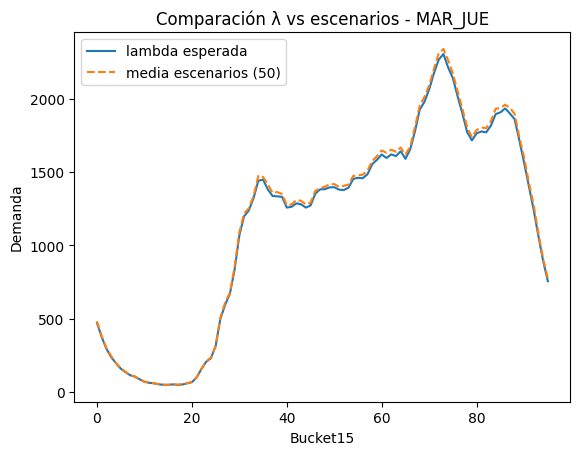

In [142]:
grupo_test = "MAR_JUE"
S = 50

escenarios_test = generar_escenarios_grupo_poisson(grupo_test, S=S, random_state=0)
print("Shape escenarios:", escenarios_test.shape)
print("Mínimo en escenarios:", escenarios_test.min())
print("Máximo en escenarios:", escenarios_test.max())

lambda_g = demanda_esperada_grupo(grupo_test)
mean_esc = escenarios_test.mean(axis=0)

diff = mean_esc - lambda_g
print("\nDiferencias promedio escenario - lambda:")
print("  min:", diff.min(), "max:", diff.max(), "mean:", diff.mean())

plt.plot(lambda_g, label="lambda esperada")
plt.plot(mean_esc, label=f"media escenarios ({S})", linestyle="--")
plt.legend()
plt.xlabel("Bucket15")
plt.ylabel("Demanda")
plt.title(f"Comparación λ vs escenarios - {grupo_test}")
plt.show()


In [143]:
# Parámetros que vienen del Excel "Datos base"
FLEET_MAX = 300           # número de vehículos
V_KMH = 25                # velocidad promedio [km/h]
AUTONOMY_KM = 350         # autonomía por carga [km]
RECHARGE_TIME_MIN = 110   # tiempo de recarga

REVENUE_FIXED = 5.5       # US$ fijo por viaje
REVENUE_PER_KM = 3.7      # US$ por km
RELOC_MARKUP = 1.25       # +25% sobre el ingreso de un viaje


In [144]:
import pandas as pd
import numpy as np

df_all = pd.read_parquet("df_all_procesado.parquet")

df_all["pickup_datetime"] = pd.to_datetime(df_all["pickup_datetime"])
df_all["dropOff_datetime"] = pd.to_datetime(df_all["dropOff_datetime"])

# Duración del viaje en minutos
df_all["trip_time_min"] = (df_all["dropOff_datetime"] - df_all["pickup_datetime"]).dt.total_seconds() / 60

# Nos quedamos con viajes razonables: entre 2 y 60 min
mask = df_all["trip_time_min"].between(2, 60)
dur_mean_min = df_all.loc[mask, "trip_time_min"].mean()
dur_mean_h = dur_mean_min / 60

# Distancia promedio del viaje usando la velocidad del Excel
avg_trip_km = dur_mean_h * V_KMH
avg_trip_km


np.float64(5.625277964620931)

In [145]:
# Ingreso promedio de un viaje de distancia promedio avg_trip_km
REV_PER_TRIP = REVENUE_FIXED + REVENUE_PER_KM * avg_trip_km

# Costo de una reubicación (oportunidad +25%)
RELOC_COST_PER_RELOC = RELOC_MARKUP * REV_PER_TRIP
REV_PER_TRIP, RELOC_COST_PER_RELOC


(np.float64(26.313528469097445), np.float64(32.89191058637181))

In [146]:
serv_por_veh_time = 15 / dur_mean_min


In [147]:
serv_por_veh_autonomy = AUTONOMY_KM / (avg_trip_km * 96)


In [148]:
SERVICIOS_POR_VEHICULO = min(serv_por_veh_time, serv_por_veh_autonomy)
SERVICIOS_POR_VEHICULO


np.float64(0.648116120885595)

In [149]:
PENAL_NO_SERV = REV_PER_TRIP  # por ejemplo, perder 1 ingreso promedio por viaje no atendido


In [150]:
def evaluar_solucion(x: np.ndarray,
                     escenarios: np.ndarray,
                     fleet_max: int = FLEET_MAX,
                     servicios_por_vehiculo: float = SERVICIOS_POR_VEHICULO,
                     rev_por_viaje: float = REV_PER_TRIP,
                     reloc_cost_per_reloc: float = RELOC_COST_PER_RELOC,
                     penalizacion_no_servido: float = PENAL_NO_SERV) -> float:
    """
    x: vector de largo 96 con nº de vehículos por bucket15.
    escenarios: matriz S x 96 con demanda de viajes por bucket.

    Retorna un "costo" a minimizar: - beneficio esperado.
    """
    x = np.array(x, dtype=float)
    x = np.clip(x, 0, fleet_max)

    S, T = escenarios.shape
    assert T == len(x), "x y escenarios deben tener el mismo nº de buckets"

    # Capacidad de servicio por bucket (viajes máximos)
    capacidades = x * servicios_por_vehiculo  # vector T

    beneficios_esc = []

    # Costo de reubicación: cada incremento positivo en x implica una reubicación
    delta_veh = np.maximum(np.diff(x), 0)  # T-1
    n_reloc_total = delta_veh.sum()
    costo_reubic = float(n_reloc_total * reloc_cost_per_reloc)

    for s in range(S):
        demanda = escenarios[s]            # vector T
        servidos = np.minimum(demanda, capacidades)
        no_serv  = demanda - servidos

        n_serv = servidos.sum()
        n_no_serv = no_serv.sum()

        ingresos = n_serv * rev_por_viaje
        penal_ns = n_no_serv * penalizacion_no_servido

        beneficio = ingresos - penal_ns - costo_reubic
        beneficios_esc.append(beneficio)

    beneficio_esp = float(np.mean(beneficios_esc))

    # Como SA minimiza, devolvemos el negativo del beneficio esperado
    return -beneficio_esp


In [151]:
def simulated_annealing(x0: np.ndarray,
                        escenarios: np.ndarray,
                        n_iter: int = 2000,
                        T0: float = 100.0,
                        alpha: float = 0.995,
                        random_state=None,
                        **eval_kwargs):
    rng = np.random.default_rng(random_state)

    x_current = np.clip(x0.astype(int), 0, FLEET_MAX)
    f_current = evaluar_solucion(x_current, escenarios, **eval_kwargs)

    x_best = x_current.copy()
    f_best = f_current

    T = T0

    for k in range(n_iter):
        # Vecino: sumar/restar 1 vehículo en un bucket al azar
        x_new = x_current.copy()
        t = rng.integers(len(x_new))
        delta = rng.choice([-1, 1])
        x_new[t] = np.clip(x_new[t] + delta, 0, FLEET_MAX)

        f_new = evaluar_solucion(x_new, escenarios, **eval_kwargs)

        if (f_new < f_current) or (rng.random() < np.exp((f_current - f_new) / T)):
            x_current, f_current = x_new, f_new
            if f_new < f_best:
                x_best, f_best = x_new, f_new

        T *= alpha

    return x_best, f_best


In [152]:
# Escenarios para día tipo MAR_JUE (modelo de demanda que ya construimos)
S = 50
escenarios_MJ = generar_escenarios_grupo_poisson("MAR_JUE", S=S, random_state=42)

T = escenarios_MJ.shape[1]  # 96
x0 = np.full(T, 150, dtype=int)  # solución inicial: 150 autos todo el día

x_opt, f_opt = simulated_annealing(
    x0=x0,
    escenarios=escenarios_MJ,
    n_iter=3000,
    T0=100.0,
    alpha=0.995,
    random_state=0
)

x_opt, f_opt


(array([171, 163, 168, 172, 163, 168, 167, 161, 159, 158, 152, 151, 151,
        151, 150, 150, 150, 150, 151, 152, 155, 161, 163, 164, 166, 158,
        167, 162, 164, 167, 164, 159, 168, 167, 161, 156, 165, 158, 163,
        167, 170, 173, 163, 167, 162, 160, 162, 170, 165, 163, 170, 165,
        157, 159, 162, 166, 181, 163, 167, 163, 162, 170, 166, 162, 166,
        163, 164, 155, 161, 162, 163, 167, 160, 163, 159, 169, 164, 161,
        160, 163, 167, 159, 160, 159, 161, 163, 165, 164, 168, 164, 167,
        162, 165, 163, 172, 166]),
 2333005.5492708157)

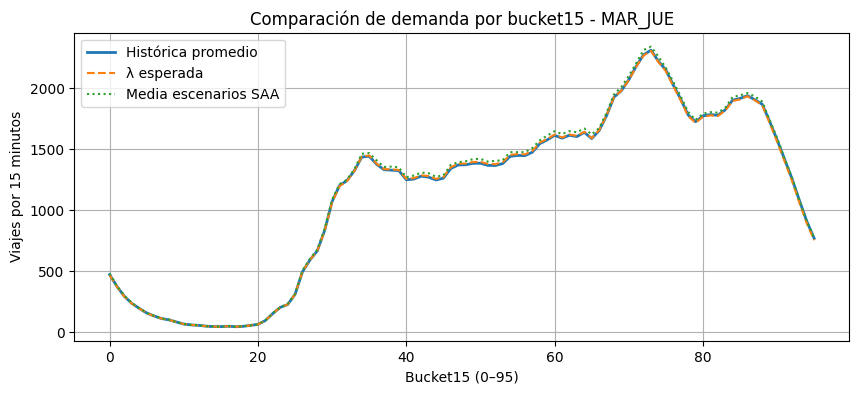

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

grupo_test = "MAR_JUE"

# 1) Demanda histórica promedio por bucket (días normales de ese grupo)
daily_profiles_fino_df = daily_profiles_fino.reset_index()

hist_grupo = (
    daily_profiles_fino_df[
        daily_profiles_fino_df["tipo_dia_fino"] == grupo_test
    ][bucket_cols]
    .mean()
    .values
)

# 2) λ esperada por bucket (lo que construimos con el modelo)
lambda_g = lambda_15_fino[grupo_test]

# 3) Media de escenarios generados con SAA
escenarios_g = generar_escenarios_grupo_poisson(grupo_test, S=100, random_state=0)
mean_esc = escenarios_g.mean(axis=0)

# Plot comparación
plt.figure(figsize=(10, 4))
plt.plot(hist_grupo, label="Histórica promedio", linewidth=2)
plt.plot(lambda_g, label="λ esperada", linestyle="--")
plt.plot(mean_esc, label="Media escenarios SAA", linestyle=":")
plt.xlabel("Bucket15 (0–95)")
plt.ylabel("Viajes por 15 minutos")
plt.title(f"Comparación de demanda por bucket15 - {grupo_test}")
plt.legend()
plt.grid(True)
plt.show()


In [154]:
# Política de flota por bucket: 150 autos todo el día
T = escenarios_g.shape[1]        # 96
x = np.full(T, 150)              # perfil plano

# Capacidad por bucket (viajes que podemos servir en cada 15 min)
capacidad = x * SERVICIOS_POR_VEHICULO  # vector de largo 96

# Media de demanda por bucket en los escenarios
demanda_media = escenarios_g.mean(axis=0)

# Nivel de servicio por bucket:
# proporción de escenarios en que la demanda del bucket se cubre completamente
nivel_servicio = (escenarios_g <= capacidad).mean(axis=0)  # promedio por columna

# Tabla resumen por bucket
df_15 = pd.DataFrame({
    "bucket15": np.arange(T),
    "demanda_media": demanda_media,
    "capacidad": capacidad,
    "nivel_servicio": nivel_servicio
})

df_15.head(20)  # primeras 20 filas


,bucket15,demanda_media,capacidad,nivel_servicio
0,0,481.70,97.217418,0.00
1,1,378.95,97.217418,0.00
2,2,300.52,97.217418,0.00
3,3,243.21,97.217418,0.00
4,4,197.51,97.217418,0.00
5,5,160.61,97.217418,0.01
6,6,137.07,97.217418,0.04
7,7,114.10,97.217418,0.18
8,8,105.44,97.217418,0.29
9,9,86.05,97.217418,0.77


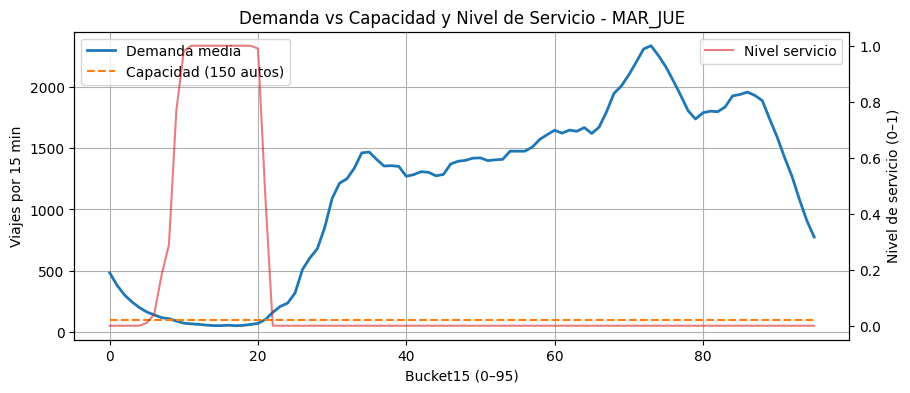

In [155]:
fig, ax1 = plt.subplots(figsize=(10,4))

ax1.plot(demanda_media, label="Demanda media", linewidth=2)
ax1.plot(capacidad, label="Capacidad (150 autos)", linestyle="--")
ax1.set_xlabel("Bucket15 (0–95)")
ax1.set_ylabel("Viajes por 15 min")
ax1.legend(loc="upper left")
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(nivel_servicio, label="Nivel servicio", color="tab:red", alpha=0.6)
ax2.set_ylabel("Nivel de servicio (0–1)")
ax2.legend(loc="upper right")

plt.title(f"Demanda vs Capacidad y Nivel de Servicio - {grupo_test}")
plt.show()


Zonal

In [156]:
# Selecciona la fecha que quieres inspeccionar (puede ser 'YYYY-MM-DD' o un objeto date)
fecha = trips_per_day["date"].iloc[0]   # por defecto: primer día disponible
# fecha = "2025-01-01"
# fecha = pd.to_datetime("2025-01-01").date()

# Normalizar a tipo date
if isinstance(fecha, str):
    fecha_dt = pd.to_datetime(fecha).date()
elif isinstance(fecha, pd.Timestamp):
    fecha_dt = fecha.date()
else:
    fecha_dt = fecha

# Filtrar df_normal para ese día
df_dia = df_normal[df_normal["date"] == fecha_dt]

if df_dia.empty:
    print(f"No hay registros para la fecha {fecha_dt}. Fechas disponibles: {trips_per_day['date'].iloc[0:10].tolist()} ...")
else:
    # Total de viajes en el día
    total_viajes_dia = len(df_dia)
    print(f"Fecha: {fecha_dt}  ->  total viajes: {total_viajes_dia}")

    # Viajes por hora (0..23)
    viajes_por_hora = df_dia.groupby("hour").size().reindex(range(24), fill_value=0)
    print("\nViajes por hora (0..23):")
    print(viajes_por_hora)

    # Opcional: mostrar las 3 horas con más viajes
    top3 = viajes_por_hora.sort_values(ascending=False).head(3)
    print("\nTop 3 horas con más viajes:")
    print(top3)

    # Si quieres ver also por bucket15 (15-minutos)
    viajes_por_bucket15 = df_dia.groupby("bucket15").size().reindex(range(96), fill_value=0)
    # ejemplo rápido: total del primer bloque horario (hora 8 = buckets 32..35)
    ejemplo_hora = 8
    b0 = ejemplo_hora * 4
    viajes_hora_ejemplo = viajes_por_bucket15.iloc[b0:b0+4].sum()
    print(f"\nEjemplo: viajes en la hora {ejemplo_hora}: {viajes_hora_ejemplo} (suma de buckets {b0}..{b0+3})")

Fecha: 2024-07-01  ->  total viajes: 68450

Viajes por hora (0..23):
hour
0     1627
1      933
2      512
3      384
4      404
5      482
6     1239
7     2238
8     3254
9     3481
10    3496
11    3786
12    4101
13    4080
14    4393
15    4327
16    4302
17    4699
18    4958
19    4016
20    3534
21    3571
22    2923
23    1710
dtype: int64

Top 3 horas con más viajes:
hour
18    4958
17    4699
14    4393
dtype: int64

Ejemplo: viajes en la hora 8: 3254 (suma de buckets 32..35)


In [157]:
import pandas as pd
import numpy as np

# Asegurar datetime
df_normal["pickup_datetime"] = pd.to_datetime(df_normal["pickup_datetime"])

# Extraer fecha, weekday y bucket15
df_normal["date"]    = df_normal["pickup_datetime"].dt.date
df_normal["weekday"] = df_normal["pickup_datetime"].dt.weekday
df_normal["hour"]    = df_normal["pickup_datetime"].dt.hour
df_normal["minute"]  = df_normal["pickup_datetime"].dt.minute
df_normal["bucket15"] = df_normal["hour"] * 4 + (df_normal["minute"] // 15)

# Tipo de día (LUN, MAR_JUE, etc.)
df_normal["tipo_dia_fino"] = df_normal["weekday"].map(grupo_weekday)

df_normal[["pickup_datetime", "date", "weekday", "tipo_dia_fino", "PUlocationID", "bucket15"]].head()


,pickup_datetime,date,weekday,tipo_dia_fino,PUlocationID,bucket15
0,2024-07-01 00:48:33,2024-07-01,0,LUN,137.0,3
1,2024-07-01 00:12:37,2024-07-01,0,LUN,164.0,0
2,2024-07-01 00:13:34,2024-07-01,0,LUN,249.0,0
3,2024-07-01 00:34:56,2024-07-01,0,LUN,164.0,2
4,2024-07-01 00:19:42,2024-07-01,0,LUN,164.0,1


In [158]:
# Eliminar viajes donde el origen es igual al destino
df_normal_filtrado = df_normal[df_normal['PUlocationID'] != df_normal['DOlocationID']]
# -----------------------------------
# número de viajes por (tipo_dia_fino, date, zona, bucket15)
demanda_zonal = (
    df_normal_filtrado
    .groupby(["tipo_dia_fino", "date", "PUlocationID", "DOlocationID", "bucket15"])
    .size()
    .reset_index(name="viajes")
)

demanda_zonal.head()


,tipo_dia_fino,date,PUlocationID,DOlocationID,bucket15,viajes
0,DOMINGO,2024-07-07,4.0,42.0,11,1
1,DOMINGO,2024-07-07,4.0,43.0,40,1
2,DOMINGO,2024-07-07,4.0,45.0,2,1
3,DOMINGO,2024-07-07,4.0,45.0,18,1
4,DOMINGO,2024-07-07,4.0,45.0,55,1


In [159]:
# Muestra viajes por bucket15 para una fecha (usa `fecha` si existe, sino primer día de trips_per_day)
fecha_sel = globals().get("fecha", None)
if fecha_sel is None:
    fecha_sel = trips_per_day["date"].iloc[0]

# Normalizar a objeto date
if isinstance(fecha_sel, str):
    fecha_dt = pd.to_datetime(fecha_sel).date()
elif isinstance(fecha_sel, pd.Timestamp):
    fecha_dt = fecha_sel.date()
else:
    fecha_dt = fecha_sel

# Filtrar y contar por bucket15
df_dia = df_normal[df_normal["date"] == fecha_dt]

if df_dia.empty:
    print(f"No hay registros para la fecha {fecha_dt}")
else:
    viajes_por_bucket15 = df_dia.groupby("bucket15").size().reindex(range(96), fill_value=0)
    df_buckets = viajes_por_bucket15.reset_index()
    df_buckets.columns = ["bucket15", "viajes"]

    print(f"Fecha: {fecha_dt}")
    print(f"Total viajes (len df_dia): {len(df_dia)}")
    print(f"Suma de todos los buckets (verificación): {int(df_buckets['viajes'].sum())}\n")

    # Mostrar todos los buckets (puedes ajustar o filtrar solo los >0)
    display(df_buckets)

    # También mostrar solo buckets con viajes
    nz = df_buckets[df_buckets["viajes"] > 0].reset_index(drop=True)
    print("\nBuckets con viajes (>0):")
    print(nz.to_string(index=False))

Fecha: 2024-07-01
Total viajes (len df_dia): 68450
Suma de todos los buckets (verificación): 68450



,bucket15,viajes
0,0,507
1,1,429
2,2,359
3,3,332
4,4,306
...,...,...
91,91,554
92,92,552
93,93,466
94,94,374



Buckets con viajes (>0):
 bucket15  viajes
        0     507
        1     429
        2     359
        3     332
        4     306
        5     228
        6     219
        7     180
        8     156
        9     127
       10     126
       11     103
       12      95
       13     100
       14      81
       15     108
       16     104
       17     106
       18      95
       19      99
       20      66
       21     104
       22     121
       23     191
       24     166
       25     257
       26     387
       27     429
       28     438
       29     546
       30     594
       31     660
       32     659
       33     776
       34     913
       35     906
       36     868
       37     904
       38     825
       39     884
       40     799
       41     887
       42     912
       43     898
       44     915
       45     912
       46     958
       47    1001
       48    1008
       49    1040
       50    1050
       51    1003
       52     984
  

In [172]:
# VERSIÓN CORRECTA: Mantiene O-D pero calcula promedio real
# ----------------------------------------------------------

# 1. Recalcular demanda_zonal desde cero (asegurar estructura O-D completa)
demanda_zonal = (
    df_normal_filtrado
    .groupby(["tipo_dia_fino", "date", "PUlocationID", "DOlocationID", "bucket15"])
    .size()
    .reset_index(name="viajes")
)

# 2. Sumar viajes totales por (tipo_dia, O, D, bucket) - MANTENER O-D
suma_viajes_OD = (
    demanda_zonal
    .groupby(["tipo_dia_fino", "PUlocationID", "DOlocationID", "bucket15"])["viajes"]
    .sum()  # Suma a través de TODOS los días (incluye días con 0 viajes)
    .reset_index(name="suma_viajes")
)

# 3. Contar días reales por tipo (denominador)
dias_por_grupo = (
    df_normal
    .groupby("tipo_dia_fino")["date"]
    .nunique()
    .to_dict()
)

# 4. Calcular Lambda REAL (Suma Total / N_Días)
suma_viajes_OD["n_dias"] = suma_viajes_OD["tipo_dia_fino"].map(dias_por_grupo)
suma_viajes_OD["lambda_gijt"] = suma_viajes_OD["suma_viajes"] / suma_viajes_OD["n_dias"]

# 5. Crear matriz final (con O-D para Gurobi)
lambda_zonal_OD_mat = suma_viajes_OD.pivot_table(
    index=["tipo_dia_fino", "PUlocationID", "DOlocationID"],  # Mantener ambos
    columns="bucket15",
    values="lambda_gijt",
    fill_value=0.0
)

# 6. Verificación
total_domingo_OD = lambda_zonal_OD_mat.loc['DOMINGO'].sum().sum()
print(f"Total λ Domingo (con O-D): {total_domingo_OD:,.0f}")
print(f"Esperado: ~84,000-90,000 ✅")

Total λ Domingo (con O-D): 84,100
Esperado: ~84,000-90,000 ✅


In [176]:
from numpy.random import default_rng

def generar_escenarios_zonal(tipo_dia_fino: str,
                             S: int = 50,
                             random_state=None):
    """
    Genera S escenarios de demanda zonal para un tipo de día (LUN, MAR_JUE, etc.)

    Retorna:
      zonas: lista de PUlocationID en ese tipo de día
      buckets: lista de bucket15 (0..95)
      escenarios: array de shape (S, n_zonas, T)
                  donde escenarios[s, i, t] = demanda de la zona i en bucket t en el escenario s
    """
    rng = default_rng(random_state)

    # Submatriz para el tipo de día g
    sub = lambda_zonal_OD_mat.loc[tipo_dia_fino]   # index = PUlocationID, columns = bucket15

    zonas = sub.index.to_list()
    buckets = sub.columns.to_list()

    lambdas = sub.values.astype(float)  # shape (n_zonas, T)
    n_zonas, T = lambdas.shape

    # Escenarios Poisson independientes
    # shape final: (S, n_zonas, T)
    escenarios = rng.poisson(lambdas[None, :, :], size=(S, n_zonas, T))

    return zonas, buckets, escenarios


In [174]:
zonas_MJ, buckets_MJ, escenarios_MJ = generar_escenarios_zonal("MAR_JUE", S=50, random_state=0)

print("N zonas MAR_JUE:", len(zonas_MJ))
print("Buckets:", len(buckets_MJ))
print("Shape escenarios_MJ:", escenarios_MJ.shape)  # (50, n_zonas, 96)


N zonas MAR_JUE: 4230
Buckets: 96
Shape escenarios_MJ: (50, 4230, 96)


In [177]:
# media de escenarios por zona y bucket
mean_esc_MJ = escenarios_MJ.mean(axis=0)  # shape (n_zonas, T)

# lambda de referencia
lambda_MJ = lambda_zonal_OD_mat.loc["MAR_JUE"].values  # misma shape

diff = mean_esc_MJ - lambda_MJ
print("Diff media escenarios - λ (MAR_JUE):")
print("  min:", diff.min(), "max:", diff.max(), "mean:", diff.mean())


Diff media escenarios - λ (MAR_JUE):
  min: -1.406896551724138 max: 1.6496551724137944 mean: -0.00010785542512431625


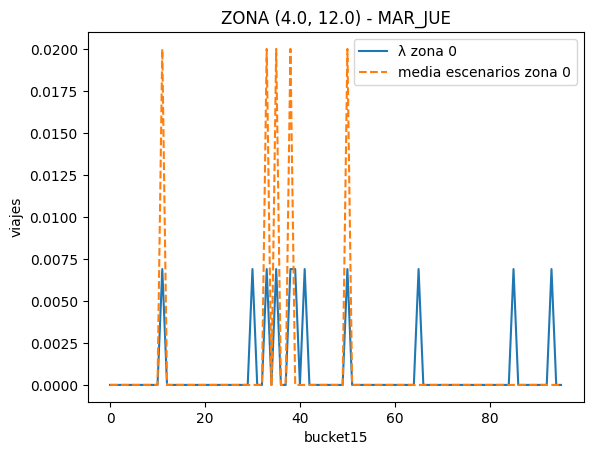

In [178]:
i0 = 0
import matplotlib.pyplot as plt

plt.plot(lambda_MJ[i0], label="λ zona 0")
plt.plot(mean_esc_MJ[i0], label="media escenarios zona 0", linestyle="--")
plt.legend()
plt.xlabel("bucket15")
plt.ylabel("viajes")
plt.title(f"ZONA {zonas_MJ[i0]} - MAR_JUE")
plt.show()


In [179]:
# Aplicar thinning al 5% sobre viajes originales para generar λ reducido
porcentaje_forecast = 0.05  # 5%

# 1) Guardar matriz completa como referencia
#lambda_zonal_mat.to_csv("lambda_zonal_OD_mat_full.csv")
print("Guardado: lambda_zonal_OD_mat_full.csv (100%)")

# 2) Thinning: muestreo Bernoulli sobre viajes filtrados
rng = np.random.default_rng(123)
mask_keep = rng.random(len(df_normal_filtrado)) < porcentaje_forecast
df_thin = df_normal_filtrado.loc[mask_keep].copy()

print(f"Viajes originales (df_normal_filtrado): {len(df_normal_filtrado)}")
print(f"Viajes tras thinning ({porcentaje_forecast*100:.1f}%): {len(df_thin)}")
print(f"Ratio exacto: {len(df_thin)/len(df_normal_filtrado):.4f}")

# 3) Recalcular demanda zonal diaria en dataset reducido
demanda_zonal_thin = (
    df_thin
    .groupby(["tipo_dia_fino", "date", "PUlocationID", "DOlocationID", "bucket15"])
    .size()
    .reset_index(name="viajes")
)

# 4) Promedio sobre días para obtener λ reducido
lambda_zonal_thin = (
    demanda_zonal_thin
    .groupby(["tipo_dia_fino", "PUlocationID", "DOlocationID", "bucket15"])['viajes']
    .mean()
    .reset_index(name="lambda_gijt")
)

lambda_zonal_mat_thin = lambda_zonal_thin.pivot_table(
    index=["tipo_dia_fino", "PUlocationID", "DOlocationID"],
    columns="bucket15",
    values="lambda_gijt",
    fill_value=0.0
)

# 5) Guardar CSV reducido que usará el modelo (sobrescribe el anterior)
lambda_zonal_mat_thin.to_csv("lambda_zonal_OD_mat.csv")
print("Guardado: lambda_zonal_OD_mat.csv (5% vía thinning)")

# 6) Métricas comparativas
sum_full = lambda_zonal_OD_mat.values.sum()
sum_thin = lambda_zonal_mat_thin.values.sum()
ratio = sum_thin / sum_full if sum_full > 0 else np.nan
print(f"\nTotal λ full: {sum_full:.2f}")
print(f"Total λ thin (5%): {sum_thin:.2f}")
print(f"Ratio λ (thin/full): {ratio:.4f}")

# Guardar escenarios y zonas de referencia (sin cambios)
np.save("escenarios_MAR_JUE.npy", escenarios_MJ)
np.save("zonas_MAR_JUE.npy", np.array(zonas_MJ))
np.save("buckets_MAR_JUE.npy", np.array(buckets_MJ))

Guardado: lambda_zonal_OD_mat_full.csv (100%)
Viajes originales (df_normal_filtrado): 34042235
Viajes tras thinning (5.0%): 1703242
Ratio exacto: 0.0500
Guardado: lambda_zonal_OD_mat.csv (5% vía thinning)

Total λ full: 479216.51
Total λ thin (5%): 576934.31
Ratio λ (thin/full): 1.2039


In [180]:
# 1. Definir tu escala
PORCENTAJE_DEMANDA = 0.05

# 2. Calcular el Lambda Escalado (Promedio del 5%)
#    (Esto es floats: 0.0675, 0.01, etc.)
lambda_zonal_scaled = lambda_zonal_OD_mat * PORCENTAJE_DEMANDA

# 3. Generar una Simulación (Realización)
#    Esto convierte los floats en enteros (0, 1, 2...) usando Poisson
#    Fija una semilla (seed) para que el "pronóstico" sea siempre el mismo
rng = np.random.default_rng(42) 
pronostico_entero = rng.poisson(lambda_zonal_scaled)

# 4. Guardar este archivo
#    Este es el que Gurobi va a leer.
pronostico_entero_df = pd.DataFrame(
    pronostico_entero, 
    index=lambda_zonal_OD_mat.index, 
    columns=lambda_zonal_OD_mat.columns
)

pronostico_entero_df.to_csv("lambda_zonal_OD_mat_representativo.csv")
print("Pronóstico Representativo (Entero y Disperso) guardado con éxito.")

Pronóstico Representativo (Entero y Disperso) guardado con éxito.


In [181]:
# --- VERIFICACIÓN DE ESCALA (DOMINGO) ---

# 1. Seleccionar solo los datos del DOMINGO
# (Asumiendo que el índice es MultiIndex [tipo_dia, PU, DO])
try:
    df_domingo = pronostico_entero_df.xs('DOMINGO', level='tipo_dia_fino')
except KeyError:
    # Por si acaso el índice no se llama así, intentamos filtrar normal
    print("Nota: No se encontró el nivel 'tipo_dia_fino', usando todo el DF o revisa el índice.")
    df_domingo = pronostico_entero_df

# 2. Definir los buckets de las 00:00 a 01:00 (Buckets 0, 1, 2, 3)
buckets_hora_0 = [0, 1, 2, 3]

# 3. Calcular sumas
viajes_hora_0 = df_domingo[buckets_hora_0].sum().sum()
viajes_total_dia = df_domingo.sum().sum()

print("\n--- RESULTADOS DE LA VERIFICACIÓN (Escala 5%) ---")
print(f"Viajes Domingo entre 00:00 y 01:00: {int(viajes_hora_0)}")
print(f"Viajes Domingo TOTAL DÍA (96 buckets): {int(viajes_total_dia)}")

# 4. Validación rápida
if 3000 < viajes_total_dia < 6000:
    print("✅ ESCALA CORRECTA: El total está en el rango esperado (~4,500).")
elif viajes_total_dia > 80000:
    print("❌ ALERTA: Sigues en la escala del 100% (~90,000). Revisa la multiplicación.")
else:
    print(f"⚠️ ESCALA INCIERTA: Total {int(viajes_total_dia)}. Verifica si es lógico.")


--- RESULTADOS DE LA VERIFICACIÓN (Escala 5%) ---
Viajes Domingo entre 00:00 y 01:00: 307
Viajes Domingo TOTAL DÍA (96 buckets): 4239
✅ ESCALA CORRECTA: El total está en el rango esperado (~4,500).


In [183]:
import pandas as pd

# 1. Load the file (adjust the path if necessary)
# You said it is in the 'Datos' folder, so:
df_real = pd.read_parquet('../Datos/df_all_reducido_github.parquet') 

# 2. Convert date and filter
df_real['pickup_datetime'] = pd.to_datetime(df_real['pickup_datetime'])
df_real['day_name'] = df_real['pickup_datetime'].dt.day_name()
df_real['date'] = df_real['pickup_datetime'].dt.date

# 3. Count trips per day
counts = df_real.groupby(['date', 'day_name']).size()

print("--- Total Trips per Day (Real Data) ---")
print(counts)

--- Total Trips per Day (Real Data) ---
date        day_name
2024-09-14  Saturday    115598
2024-09-15  Sunday       89889
2024-09-16  Monday       87694
dtype: int64


In [184]:
import pandas as pd

# Ajusta la ruta si es necesario (tú usaste '../Datos/' antes)
ruta_completa = '../Datos/df_all_procesado.parquet'

print(f"Cargando archivo completo: {ruta_completa}...")

try:
    df_full = pd.read_parquet(ruta_completa)
    
    # Asegurar formato de fecha
    df_full['pickup_datetime'] = pd.to_datetime(df_full['pickup_datetime'])
    df_full['day_name'] = df_full['pickup_datetime'].dt.day_name()
    df_full['date'] = df_full['pickup_datetime'].dt.date

    # --- 1. ANÁLISIS DE DOMINGOS ---
    # Filtramos solo los domingos para comparar con tu día de simulación
    df_domingos = df_full[df_full['day_name'] == 'Sunday'].copy()
    
    print(f"\n--- Estadísticas Generales de DOMINGOS ---")
    print(f"Cantidad de Domingos encontrados: {df_domingos['date'].nunique()}")
    
    promedio_total = df_domingos.groupby('date').size().mean()
    print(f"Promedio de viajes TOTALES en Domingo: {promedio_total:,.0f}")

    # --- 2. EL DIAGNÓSTICO CLAVE: Desglose por TIPO ---
    # Aquí veremos cuánto aporta 'taxi' y cuánto 'fhv' (Uber/Lyft)
    if 'tipo' in df_domingos.columns:
        print(f"\n--- Desglose por Tipo de Vehículo (Promedio Domingo) ---")
        
        # Agrupar por fecha y tipo, y luego promediar
        conteo_por_tipo = df_domingos.groupby(['date', 'tipo']).size().unstack(fill_value=0)
        promedio_por_tipo = conteo_por_tipo.mean()
        
        print(promedio_por_tipo)
        
        print("\n--- Ejemplo de un Domingo específico (último disponible) ---")
        ultima_fecha = df_domingos['date'].max()
        print(f"Fecha: {ultima_fecha}")
        print(conteo_por_tipo.loc[ultima_fecha])
        
    else:
        print("\n⚠️ No se encontró la columna 'tipo' en el dataframe.")

except Exception as e:
    print(f"Error al leer el archivo: {e}")

Cargando archivo completo: ../Datos/df_all_procesado.parquet...

--- Estadísticas Generales de DOMINGOS ---
Cantidad de Domingos encontrados: 52
Promedio de viajes TOTALES en Domingo: 88,382

--- Desglose por Tipo de Vehículo (Promedio Domingo) ---
tipo
fhv       980.884615
taxi    87400.788462
dtype: float64

--- Ejemplo de un Domingo específico (último disponible) ---
Fecha: 2025-06-29
tipo
fhv       895
taxi    94819
Name: 2025-06-29, dtype: int64
